In [ ]:
pip install pandas numpy matplotlib seaborn statsmodels

In [ ]:
import pandas as pd

# Replace 'Walmart.csv' with the correct path to your dataset
data = pd.read_csv('/content/Walmart.csv')

# Check first 5 rows to confirm it loaded correctly
print(data.head())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [ ]:
# Convert the Date column to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')

# Sort by date
data = data.sort_values('Date')

# Check
print(data.head())

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1 2010-02-05    1643690.90             0        42.31       2.572   
1287     10 2010-02-05    2193048.75             0        54.34       2.962   
5148     37 2010-02-05     536006.73             0        45.97       2.572   
2288     17 2010-02-05     789036.02             0        23.11       2.666   
4147     30 2010-02-05     465108.52             0        39.05       2.572   

             CPI  Unemployment  
0     211.096358         8.106  
1287  126.442065         9.765  
5148  209.852966         8.554  
2288  126.442065         6.548  
4147  210.752605         8.324  


In [ ]:
sales_series = data.groupby('Date')['Weekly_Sales'].sum()


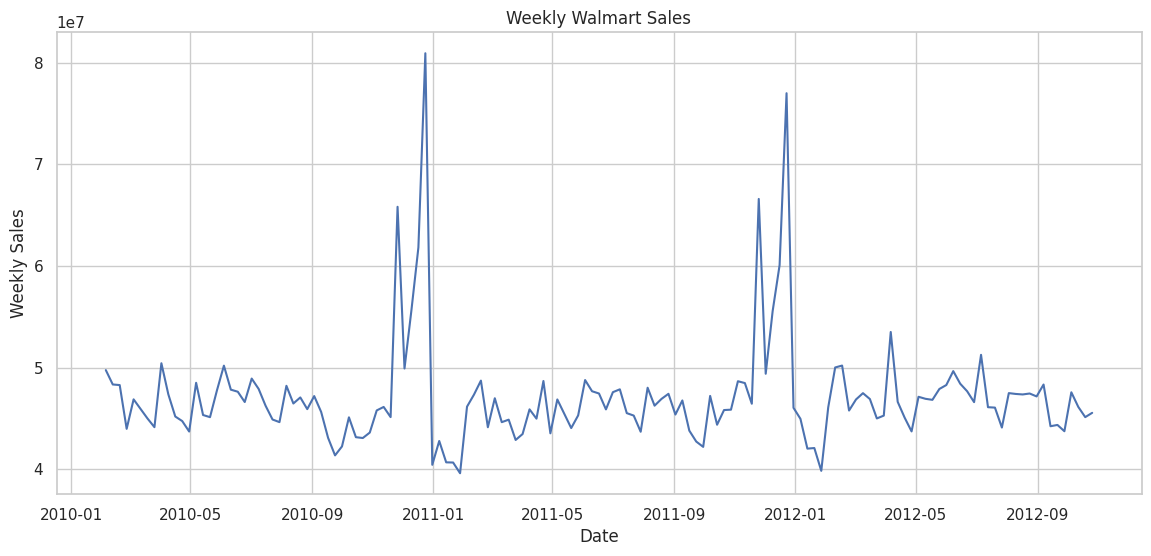

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

plt.figure(figsize=(14,6))
plt.plot(sales_series)
plt.title('Weekly Walmart Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()


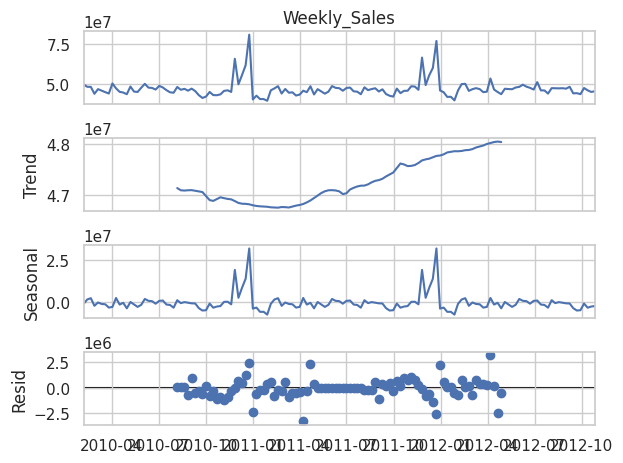

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(sales_series, model='additive', period=52)  # yearly seasonality
decomposition.plot()
plt.show()


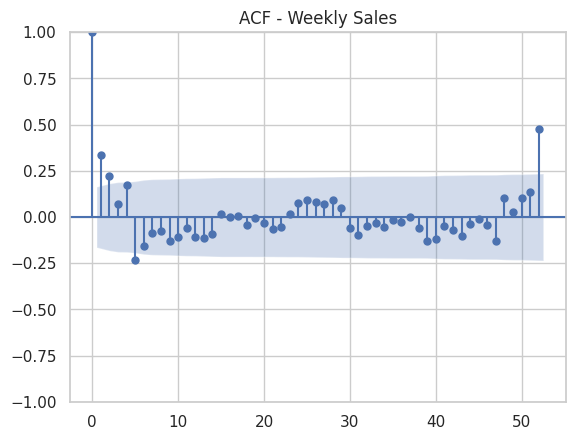

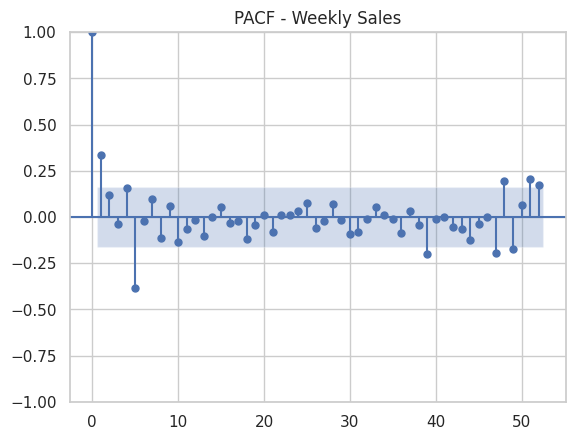

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(sales_series, lags=52)
plt.title("ACF - Weekly Sales")
plt.show()

plot_pacf(sales_series, lags=52)
plt.title("PACF - Weekly Sales")
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(sales_series)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])


ADF Statistic: -5.908297957186335
p-value: 2.675979158986003e-07


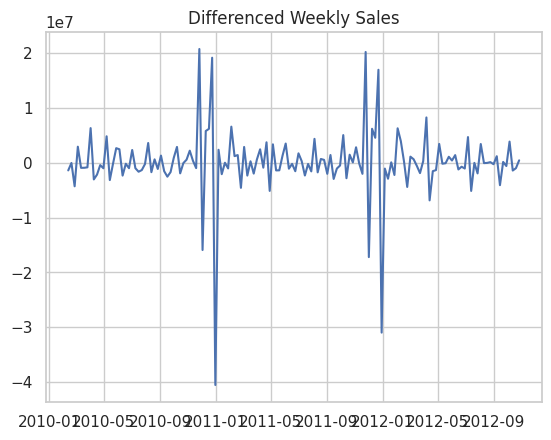

p-value after differencing: 3.922578707076903e-09


In [ ]:
sales_diff = sales_series.diff().dropna()

# Plot differenced series
plt.plot(sales_diff)
plt.title('Differenced Weekly Sales')
plt.show()

# Test stationarity again
adf_result_diff = adfuller(sales_diff)
print('p-value after differencing:', adf_result_diff[1])
